# 😊 Notebook 2 — Emotion Detection CNN-BiLSTM
**Task:** Detect emotion from audio (neutral / happy / sad / angry)
**Dataset:** RAVDESS — 24 actors, 8 emotions
**Architecture:** CNN + BiLSTM
**Hardware:** Kaggle T4 GPU

---


## Step 1 — Clean Disk

In [3]:
import os, shutil

print('🧹 Cleaning up disk space...')
dirs_to_clean = [
    '/kaggle/working/hf_cache',
    '/kaggle/working/best_emotion_model.pth',
    '/kaggle/working/emotion_results.png',
]
for path in dirs_to_clean:
    try:
        if os.path.isdir(path):  shutil.rmtree(path)
        elif os.path.isfile(path): os.remove(path)
    except: pass

total, used, free = shutil.disk_usage('/kaggle/working')
print(f'💾 Free: {free/1e9:.1f} GB')
print('✅ Ready')

🧹 Cleaning up disk space...
💾 Free: 20.9 GB
✅ Ready


## Step 2 — Install Dependencies

In [4]:
!pip install -q librosa soundfile datasets scikit-learn matplotlib seaborn
!pip install -q torch torchaudio
print('✅ All packages installed')

✅ All packages installed


## Step 3 — Kaggle Cache Fix

In [5]:
import os

os.makedirs('/kaggle/working/hf_cache', exist_ok=True)
os.makedirs('/kaggle/working/hf_cache/datasets', exist_ok=True)
os.makedirs('/kaggle/working/hf_cache/hub', exist_ok=True)

os.environ['HF_HOME']               = '/kaggle/working/hf_cache'
os.environ['HF_DATASETS_CACHE']     = '/kaggle/working/hf_cache/datasets'
os.environ['TRANSFORMERS_CACHE']    = '/kaggle/working/hf_cache/hub'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/kaggle/working/hf_cache/hub'

print('✅ HuggingFace cache redirected to /kaggle/working/hf_cache')

✅ HuggingFace cache redirected to /kaggle/working/hf_cache


## Step 4 — GPU Check

In [6]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — enable GPU in Kaggle settings')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Step 5 — Load RAVDESS Dataset

In [11]:
import os
import numpy as np
import soundfile as sf
from pathlib import Path

RAVDESS_DIR = '/kaggle/working/ravdess'

# Parse filename to get emotion label
# RAVDESS filename format: 03-01-01-01-01-01-01.wav
# Position 3 (index 2) = emotion: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised

samples = []
for actor_dir in sorted(Path(RAVDESS_DIR).iterdir()):
    if not actor_dir.is_dir(): continue
    for wav_file in sorted(actor_dir.glob('*.wav')):
        parts = wav_file.stem.split('-')
        emotion_id = int(parts[2])  # 3rd element = emotion
        samples.append({'path': str(wav_file), 'label': emotion_id - 1})  # 0-indexed

print(f'✅ Total samples: {len(samples)}')
print(f'   Emotion labels found: {sorted(set(s["label"] for s in samples))}')

✅ Total samples: 1440
   Emotion labels found: [0, 1, 2, 3, 4, 5, 6, 7]


## Step 6 — Emotion Mapping

In [12]:
# RAVDESS: 0=neutral, 1=calm, 2=happy, 3=sad, 4=angry, 5=fearful, 6=disgust, 7=surprised
EMOTION_MAP = {
    0: 'neutral',
    1: 'neutral',   # calm → neutral
    2: 'happy',
    3: 'sad',
    4: 'angry',
    5: 'neutral',   # fearful → neutral
    6: 'angry',     # disgust → angry
    7: 'happy',     # surprised → happy
}

LABEL2IDX = {'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}

print('✅ Emotion mapping ready')
print(f'   Classes: {LABEL2IDX}')

✅ Emotion mapping ready
   Classes: {'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3}


## Step 7 — Extract MFCC + Delta Features
 (Mel-Frequency Cepstral Coefficients) represent how the human ear perceives sound

In [ ]:
import librosa
import numpy as np
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

SR      = 22050 # Sample rate for audio processing
N_MFCC  = 40    # Number of MFCC coefficients to extract
MAX_LEN = 200 # Max number of time frames (pad/truncate to this length)

def extract_mfcc(audio_array, sr=SR):
    if audio_array.ndim > 1:
        audio_array = audio_array.mean(axis=0)
    audio_array = audio_array.astype(np.float32)
    mfcc   = librosa.feature.mfcc(y=audio_array, sr=sr, n_mfcc=N_MFCC)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat   = np.vstack([mfcc, delta, delta2])
    feat   = (feat - feat.mean(axis=1, keepdims=True)) / (feat.std(axis=1, keepdims=True) + 1e-8)
    if feat.shape[1] < MAX_LEN:
        feat = np.pad(feat, ((0,0), (0, MAX_LEN - feat.shape[1])))
    else:
        feat = feat[:, :MAX_LEN]
    return feat

def process_sample(sample):
    try:
        audio, sr_s = librosa.load(sample['path'], sr=SR, mono=True)
        feat  = extract_mfcc(audio, SR)
        label = LABEL2IDX[EMOTION_MAP[sample['label']]]
        return feat, label
    except Exception:
        return None, None

print('Extracting MFCC + Delta features (parallel)...')
X, y, skipped = [], [], 0

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(process_sample, s): s for s in samples}
    for future in tqdm(as_completed(futures), total=len(samples)):
        feat, label = future.result()
        if feat is not None:
            X.append(feat)
            y.append(label)
        else:
            skipped += 1

X = np.array(X)
y = np.array(y)
print(f'✅ {X.shape[0]} samples extracted, {skipped} skipped')
print(f'   Feature shape: {X.shape}')
print('\nClass distribution:')
for idx, name in IDX2LABEL.items():
    count = (y == idx).sum()
    print(f'  {name}: {count} ({count/len(y)*100:.1f}%)')

Extracting MFCC + Delta features (parallel)...


  0%|          | 0/1440 [00:00<?, ?it/s]

✅ 1440 samples extracted, 0 skipped
   Feature shape: (1440, 120, 200)

Class distribution:
  neutral: 480 (33.3%)
  happy: 384 (26.7%)
  sad: 192 (13.3%)
  angry: 384 (26.7%)


## Step 8 — Train / Val / Test Split

In [15]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

class EmotionDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.FloatTensor(features).unsqueeze(1)  # (N, 1, 120, 200)
        self.y = torch.LongTensor(labels)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH = 32
train_loader = DataLoader(EmotionDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(EmotionDataset(X_val,   y_val),   batch_size=BATCH)
test_loader  = DataLoader(EmotionDataset(X_test,  y_test),  batch_size=BATCH)
print('✅ DataLoaders ready')

Train: 1008 | Val: 216 | Test: 216
✅ DataLoaders ready


## Step 9 — CNN-BiLSTM Model

In [16]:
import torch.nn as nn

class CNN_BiLSTM_Emotion(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.cnn1 = nn.Sequential(
            nn.Conv2d(1, 32, (3,3), padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, (3,3), padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.25),
        )
        self.cnn2 = nn.Sequential(
            nn.Conv2d(32, 64, (3,3), padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, (3,3), padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.25),
        )
        self.cnn3 = nn.Sequential(
            nn.Conv2d(64, 128, (3,3), padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.25),
        )
        self.bilstm = nn.LSTM(128*15, 256, num_layers=2, batch_first=True,
                               bidirectional=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.cnn1(x); x = self.cnn2(x); x = self.cnn3(x)
        B, C, H, W = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, W, C*H)
        x, _ = self.bilstm(x)
        return self.classifier(x[:, -1, :])

model_emo = CNN_BiLSTM_Emotion(n_classes=4).to(device)
total = sum(p.numel() for p in model_emo.parameters())
print(f'CNN-BiLSTM: {total:,} parameters')

dummy = torch.randn(2, 1, 120, 200).to(device)
print(f'Input: {dummy.shape} → Output: {model_emo(dummy).shape} ✅')

CNN-BiLSTM: 6,243,172 parameters
Input: torch.Size([2, 1, 120, 200]) → Output: torch.Size([2, 4]) ✅


## Step 10 — Train & Evaluate & Plot Results

In [20]:
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

# ── Simple dataset (no augmentation) ─────────────────────────────────────────
class_counts   = np.bincount(y_train)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(EmotionDataset(X_train, y_train), batch_size=16, sampler=sampler)
val_loader   = DataLoader(EmotionDataset(X_val,   y_val),   batch_size=16)
test_loader  = DataLoader(EmotionDataset(X_test,  y_test),  batch_size=16)

# ── Rebuild model ─────────────────────────────────────────────────────────────
model_emo = CNN_BiLSTM_Emotion(n_classes=4).to(device)

weights   = torch.FloatTensor(class_weights / class_weights.sum() * 4).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(model_emo.parameters(), lr=3e-4, weight_decay=5e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

EPOCHS       = 60
best_val_acc = 0
patience     = 15
no_improve   = 0

print(f'Training for {EPOCHS} epochs...')

for epoch in range(EPOCHS):
    model_emo.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model_emo(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model_emo.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model_emo.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model_emo(X_batch)
            val_loss += criterion(out, y_batch).item()
            correct  += (out.argmax(1) == y_batch).sum().item()
            total    += y_batch.size(0)

    val_acc = correct / total
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model_emo.state_dict(), '/kaggle/working/best_emotion_model.pth')
    else:
        no_improve += 1

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss/len(train_loader):.4f} | Val: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc*100:.1f}%')

    if no_improve >= patience:
        print(f'\n⏹ Early stopping at epoch {epoch+1}')
        break

print(f'\n🏆 Best validation accuracy: {best_val_acc*100:.1f}%')

Training for 60 epochs...
Epoch   5/60 | Train: 1.2797 | Val: 1.4069 | Val Acc: 19.4%
Epoch  10/60 | Train: 1.2082 | Val: 1.2554 | Val Acc: 38.4%
Epoch  15/60 | Train: 1.1347 | Val: 1.1569 | Val Acc: 44.4%
Epoch  20/60 | Train: 1.0426 | Val: 1.2357 | Val Acc: 38.9%
Epoch  25/60 | Train: 0.8670 | Val: 1.0361 | Val Acc: 48.1%
Epoch  30/60 | Train: 0.7933 | Val: 1.0050 | Val Acc: 52.8%
Epoch  35/60 | Train: 0.5729 | Val: 0.9599 | Val Acc: 59.3%
Epoch  40/60 | Train: 0.5263 | Val: 1.1213 | Val Acc: 61.6%
Epoch  45/60 | Train: 0.4448 | Val: 1.1332 | Val Acc: 59.7%
Epoch  50/60 | Train: 0.4558 | Val: 1.0786 | Val Acc: 63.0%

⏹ Early stopping at epoch 53

🏆 Best validation accuracy: 63.9%


## Step 11 — Evaluate & Plot Results


📊 Test Set Results:
              precision    recall  f1-score   support

     neutral       0.67      0.60      0.63        72
       happy       0.63      0.62      0.63        58
         sad       0.40      0.28      0.33        29
       angry       0.59      0.77      0.67        57

    accuracy                           0.61       216
   macro avg       0.57      0.57      0.56       216
weighted avg       0.60      0.61      0.60       216



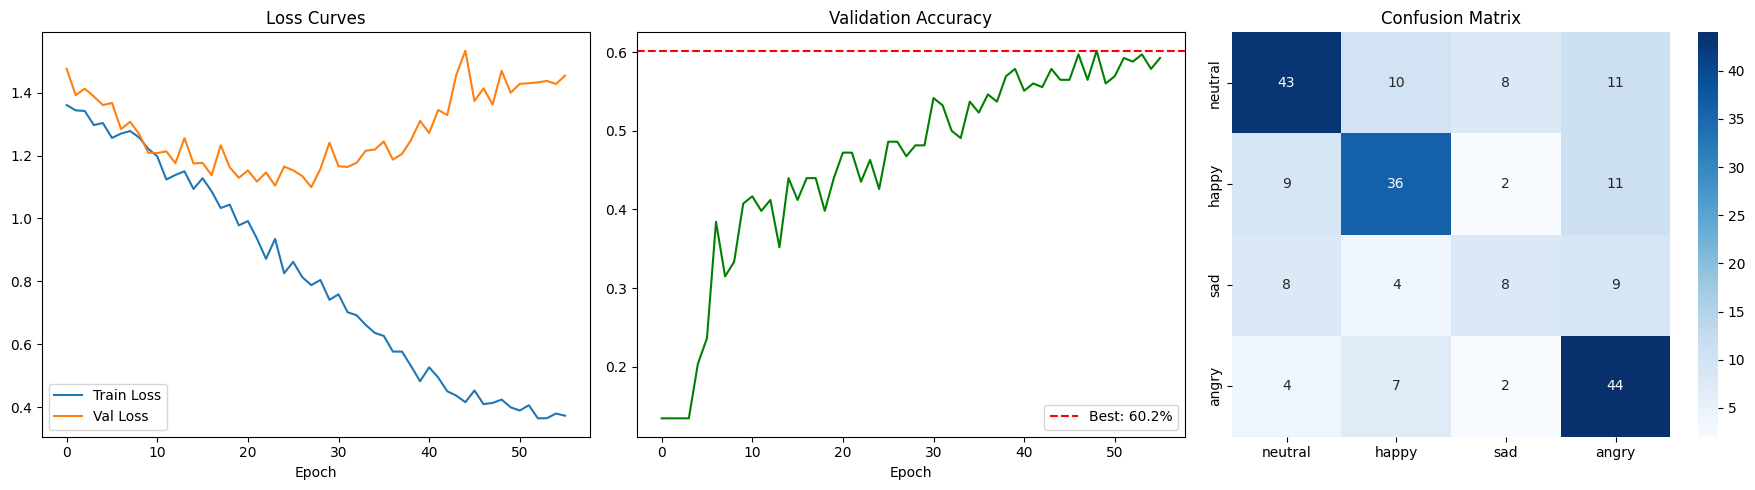


✅ Plot saved to emotion_results.png

✅ Files ready in Kaggle output panel:
   best_emotion_model.pth  (25.0 MB)
   emotion_results.png

→ You need best_emotion_model.pth for Notebook 5 (Gradio demo)


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

# ── Evaluation + Plots ────────────────────────────────────────────────────────
model_emo.load_state_dict(torch.load('/kaggle/working/best_emotion_model.pth'))
model_emo.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        out = model_emo(X_batch.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

print('\n📊 Test Set Results:')
print('=' * 40)
print(classification_report(all_labels, all_preds, target_names=list(LABEL2IDX.keys())))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses,   label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(val_accs, color='green')
axes[1].axhline(y=best_val_acc, color='r', linestyle='--',
                label=f'Best: {best_val_acc*100:.1f}%')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=list(LABEL2IDX.keys()),
            yticklabels=list(LABEL2IDX.keys()), cmap='Blues')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('/kaggle/working/emotion_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Plot saved to emotion_results.png')
print(f'\n✅ Files ready in Kaggle output panel:')
print(f'   best_emotion_model.pth  ({os.path.getsize("/kaggle/working/best_emotion_model.pth") / 1e6:.1f} MB)')
print(f'   emotion_results.png')
print('\n→ You need best_emotion_model.pth for Notebook 5 (Gradio demo)')

## Step 12 — Save Model for Download

In [24]:
import os

print('✅ Files ready in Kaggle output panel:')
print(f'   best_emotion_model.pth  ({os.path.getsize("/kaggle/working/best_emotion_model.pth") / 1e6:.1f} MB)')
print('   emotion_results.png')
print()
print('→ Click Output panel on the right side of Kaggle to download')
print('→ You need best_emotion_model.pth for Notebook 5 (Gradio demo)')

✅ Files ready in Kaggle output panel:
   best_emotion_model.pth  (25.0 MB)
   emotion_results.png

→ Click Output panel on the right side of Kaggle to download
→ You need best_emotion_model.pth for Notebook 5 (Gradio demo)
